In [1]:
import os
import json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Constants
PERSONAL_DB = "/scratch/gpfs/GRIFFITHS/hl4291/personal.db"
EPSILON = 1e-6
LIMIT_N = 1000  # Use None for full dataset

In [13]:
# 1. Connect
# src_dir = os.path.dirname(os.path.abspath(__file__))
print(f"Connecting to {PERSONAL_DB}...")
conn = duckdb.connect(database=PERSONAL_DB, read_only=False)

# 2. SQL Pre-calculation
limit_clause = f"LIMIT {LIMIT_N}" if LIMIT_N is not None else ""
print(f"Creating SQL tables _selected_moves and stats (limit={LIMIT_N or 'FULL'})...")

conn.execute(f"""
    CREATE OR REPLACE TABLE _selected_moves AS
    SELECT 
        gid,
        move_ply,
        player_clock_time,
        opponent_clock_time, 
        ln(player_clock_time + {EPSILON}) as ln_player_clock_time, 
        ln(opponent_clock_time + {EPSILON}) as ln_opponent_clock_time, 
        ln(move_time + {EPSILON}) as ln_move_time,
        ntile(10) over (order by move_ply) as qbin_move_ply,
        ntile(10) over (order by player_clock_time) as qbin_player_clock_time,
        ntile(10) over (order by opponent_clock_time) as qbin_opponent_clock_time
    FROM (
        SELECT *
        FROM selected_moves
        {limit_clause}
    );
""")

# 3. Get Counts from processed table
print("Getting processed dataset counts...")
n_games = conn.execute("SELECT count(distinct gid) FROM _selected_moves").fetchone()[0]
n_moves = conn.execute("SELECT count(*) FROM _selected_moves").fetchone()[0]
print(f"Total Games: {n_games:,} | Total Moves: {n_moves:,}")

Connecting to /scratch/gpfs/GRIFFITHS/hl4291/personal.db...
Creating SQL tables _selected_moves and stats (limit=1000)...
Getting processed dataset counts...
Total Games: 15 | Total Moves: 1,000


In [14]:
df = conn.execute("SELECT * FROM _selected_moves").df()

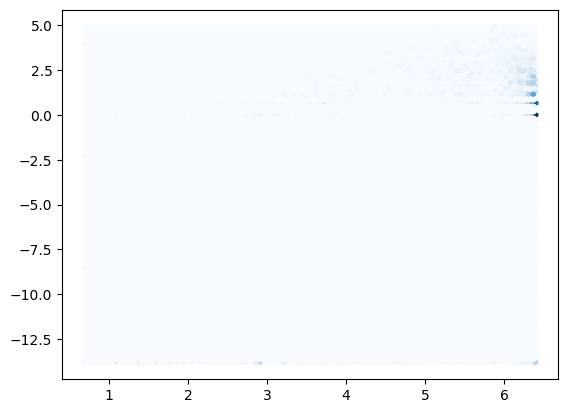

In [16]:
fig, ax = plt.subplots(1, 1)
ax.hexbin(df.ln_player_clock_time, df.ln_move_time, cmap = "Blues")

In [12]:
df.ln_player_clock_time

0      0.845098
1      1.041393
2      1.176091
3      1.230449
4      1.176091
         ...   
995    2.778151
996    2.778151
997    2.778151
998    2.778151
999    2.778151
Name: ln_player_clock_time, Length: 1000, dtype: float64

In [10]:
np.log(df.player_clock_time)

0      1.945910
1      2.397895
2      2.708050
3      2.833213
4      2.708050
         ...   
995    6.396930
996    6.396930
997    6.396930
998    6.396930
999    6.396930
Name: player_clock_time, Length: 1000, dtype: float32

In [9]:
df.move_ply

0      154
1      152
2      148
3      142
4      150
      ... 
995      2
996      1
997      3
998      2
999      1
Name: move_ply, Length: 1000, dtype: uint16